# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
import os
import json
import shutil
from datetime import datetime
from tqdm.notebook import tqdm

In [2]:
# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils import resample

In [3]:
# Deep learning imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaModel
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

# Set Random Seed

In [4]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# 1. Load Dataset

In [5]:
print("📚 Bloom's Taxonomy Classification Pipeline")
print("=" * 50)
print("\n1. 📁 Loading Dataset...")
try:
    df = pd.read_csv('/kaggle/input/blooms-taxonomy-dataset/blooms_taxonomy_dataset.csv')
    print(f"✅ Dataset loaded successfully!")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {list(df.columns)}")
    print(f"\nFirst 3 rows:")
    print(df.head(3))
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    print("Creating sample dataset for demonstration...")

    # Create sample data if file not found
    sample_data = {
        'Questions': [
            'What is the capital of France?',
            'Analyze the impact of climate change on agriculture',
            'Create a business plan for a new startup',
            'Remember the basic steps of photosynthesis',
            'Evaluate the effectiveness of different teaching methods',
            'List the primary colors',
            'Compare and contrast democracy and autocracy',
            'Design a new mobile application',
            'What are the main components of DNA?',
            'Assess the validity of this research study'
        ],
        'Category': ['BT1', 'BT4', 'BT5', 'BT1', 'BT5', 'BT1', 'BT4', 'BT5', 'BT1', 'BT5']
    }
    df = pd.DataFrame(sample_data)
    print("✅ Sample dataset created!")

# 2. Text Preprocessing

In [6]:
print("\n2. 🧹 Text Preprocessing...")
def preprocess_text(text):
    """
    Preprocessing function to clean text data
    """
    if pd.isna(text):
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs/links
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)

    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\?\!\-]', '', text)

    # Normalize multiple spaces
    text = re.sub(r'\s+', ' ', text)

    # Strip leading/trailing whitespace
    text = text.strip()

    return text

# Apply preprocessing
df['Questions_clean'] = df['Questions'].apply(preprocess_text)
print("✅ Text preprocessing completed!")


2. 🧹 Text Preprocessing...
✅ Text preprocessing completed!


# 3. Display initial label distribution


3. 📊 Initial Label Distribution:
Category
BT1    2582
BT2    1801
BT3    1508
BT4    1293
BT5     783
BT6     800
Name: count, dtype: int64


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'BT1'),
  Text(1, 0, 'BT2'),
  Text(2, 0, 'BT3'),
  Text(3, 0, 'BT4'),
  Text(4, 0, 'BT5'),
  Text(5, 0, 'BT6')])

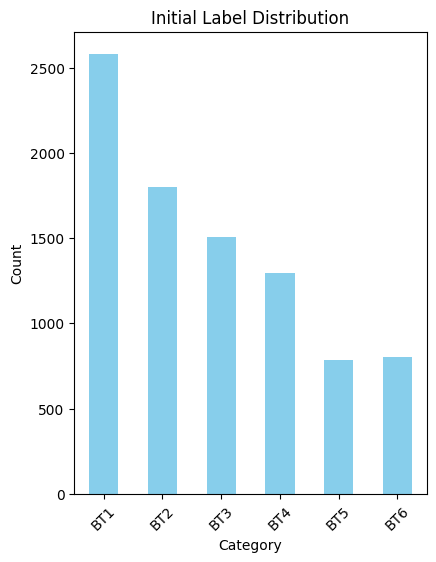

In [7]:
print("\n3. 📊 Initial Label Distribution:")
label_counts = df['Category'].value_counts().sort_index()
print(label_counts)

# Visualize distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar', color='skyblue')
plt.title('Initial Label Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 4. Undersampling for balanced dataset


4. ⚖️ Balancing Dataset...
Minimum count: 783
✅ Balanced dataset shape: (4698, 3)
Balanced distribution:
Category
BT1    783
BT2    783
BT3    783
BT4    783
BT5    783
BT6    783
Name: count, dtype: int64


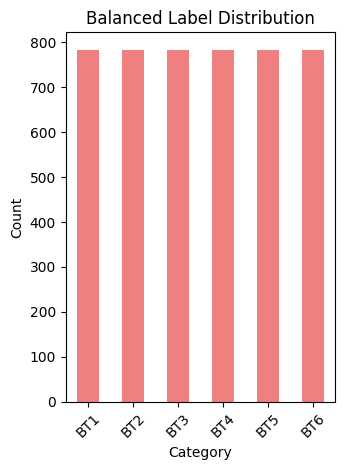

In [8]:
print("\n4. ⚖️ Balancing Dataset...")
min_count = label_counts.min()
print(f"Minimum count: {min_count}")

# Perform undersampling
balanced_dfs = []
for category in df['Category'].unique():
    category_df = df[df['Category'] == category]

    if len(category_df) > min_count:
        # Undersample to min_count
        category_balanced = resample(category_df,
                                   replace=False,
                                   n_samples=min_count,
                                   random_state=42)
    else:
        category_balanced = category_df

    balanced_dfs.append(category_balanced)

# Combine balanced data
df_balanced = pd.concat(balanced_dfs, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Balanced dataset shape: {df_balanced.shape}")
balanced_counts = df_balanced['Category'].value_counts().sort_index()
print("Balanced distribution:")
print(balanced_counts)

# Visualize balanced distribution
plt.subplot(1, 2, 2)
balanced_counts.plot(kind='bar', color='lightcoral')
plt.title('Balanced Label Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Train-Test Split

In [9]:
print("\n6. 🔄 Train-Test Split...")
X_text = df_balanced['Questions_clean'].values
y = df_balanced['Category'].values

X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train set: {len(X_text_train)} samples")
print(f"✅ Test set: {len(X_text_test)} samples")


6. 🔄 Train-Test Split...
✅ Train set: 3758 samples
✅ Test set: 940 samples


# 7. BERT Setup

In [10]:
print("\n7. 🤖 Setting up BERT...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


7. 🤖 Setting up BERT...
Device: cuda


In [11]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModel.from_pretrained('bert-base-uncased').to(device)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [12]:
# Freeze BERT parameters to reduce training time
for param in bert_model.parameters():
    param.requires_grad = False

print("✅ BERT model loaded and frozen!")

✅ BERT model loaded and frozen!


# 8. Dataset Class

In [13]:
class BloomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.label_encoder = LabelEncoder()
        self.label_encoder.fit(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.LongTensor([self.label_encoder.transform([self.labels[idx]])[0]])
        }

# Create datasets
train_dataset = BloomDataset(X_text_train, y_train, tokenizer)
test_dataset = BloomDataset(X_text_test, y_test, tokenizer)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"✅ Datasets created!")
print(f"   Number of classes: {len(train_dataset.label_encoder.classes_)}")
print(f"   Classes: {train_dataset.label_encoder.classes_}")

✅ Datasets created!
   Number of classes: 6
   Classes: ['BT1' 'BT2' 'BT3' 'BT4' 'BT5' 'BT6']


# 9. Modified Model Architecture with Unfrozen BERT

In [14]:
class BloomClassifier(nn.Module):
    def __init__(self, bert_model, num_classes, hidden_dim=256, variant='cnn_lstm', unfreeze_layers=2):
        super(BloomClassifier, self).__init__()
        assert variant in ['cnn', 'lstm', 'cnn_lstm'], "Invalid model variant"
        self.variant = variant

        self.bert = bert_model
        self.bert_dim = 768

        self.unfreeze_bert_layers(unfreeze_layers)

        # CNN layers
        if variant in ['cnn', 'cnn_lstm']:
            self.conv1 = nn.Conv1d(self.bert_dim, 128, kernel_size=3, padding=1)
            self.conv2 = nn.Conv1d(128, 64, kernel_size=3, padding=1)
            self.pool = nn.AdaptiveMaxPool1d(1)

        # LSTM
        if variant in ['lstm', 'cnn_lstm']:
            self.lstm = nn.LSTM(self.bert_dim, hidden_dim // 2, batch_first=True,
                                bidirectional=True, dropout=0.2)

        # Combined dimension
        combined_dim = 0
        if variant in ['cnn', 'cnn_lstm']:
            combined_dim += 64
        if variant in ['lstm', 'cnn_lstm']:
            combined_dim += hidden_dim

        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def unfreeze_bert_layers(self, num_layers=2):
        for param in self.bert.parameters():
            param.requires_grad = False

        total_layers = len(self.bert.encoder.layer)
        for i in range(total_layers - num_layers, total_layers):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = True

        if hasattr(self.bert, 'pooler') and self.bert.pooler is not None:
            for param in self.bert.pooler.parameters():
                param.requires_grad = True

        print(f"Unfrozen last {num_layers} layers of BERT (layers {total_layers - num_layers} to {total_layers - 1})")

    def get_parameter_groups(self):
        bert_params = [p for n, p in self.bert.named_parameters() if p.requires_grad]
        other_params = [p for n, p in self.named_parameters() if p.requires_grad and not n.startswith('bert')]
        return [
            {'params': bert_params, 'lr': 1e-5, 'name': 'bert'},
            {'params': other_params, 'lr': 2e-4, 'name': 'classifier'}
        ]

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = bert_output.last_hidden_state

        features = []

        if self.variant in ['cnn', 'cnn_lstm']:
            cnn_input = sequence_output.permute(0, 2, 1)
            cnn_out = F.relu(self.conv1(cnn_input))
            cnn_out = F.relu(self.conv2(cnn_out))
            cnn_features = self.pool(cnn_out).squeeze(-1)
            features.append(cnn_features)

        if self.variant in ['lstm', 'cnn_lstm']:
            lstm_out, (hidden, _) = self.lstm(sequence_output)
            lstm_features = hidden.permute(1, 0, 2).contiguous().view(hidden.size(1), -1)
            features.append(lstm_features)

        combined = torch.cat(features, dim=1)
        output = self.classifier(combined)
        return output

# Initialize model with unfreezing
num_classes = len(train_dataset.label_encoder.classes_)

# Create model with unfreeze_layers parameter
variant = 'cnn'  # or 'lstm', 'cnn_lstm'
model = BloomClassifier(bert_model, num_classes=num_classes, variant=variant, unfreeze_layers=2)
model.to(device)

print(f"✅ Model created!")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Check which parameters are trainable
bert_trainable = sum(p.numel() for p in model.bert.parameters() if p.requires_grad)
other_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad and not any(p is rp for rp in model.bert.parameters()))

print(f"   BERT trainable params: {bert_trainable:,}")
print(f"   Other trainable params: {other_trainable:,}")

# 10. Training Setup with Discriminative Fine-tuning

In [15]:
print("\n10. 🏋️ Training Setup with Discriminative Fine-tuning...")

import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        logpt = F.log_softmax(inputs, dim=1)
        pt = torch.exp(logpt)
        logpt = logpt.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = pt.gather(1, targets.unsqueeze(1)).squeeze(1)
        loss = -self.alpha * (1 - pt) ** self.gamma * logpt
        return loss.mean() if self.reduction == 'mean' else loss.sum()

criterion = FocalLoss(alpha=1.0, gamma=2.0)

# Setup discriminative optimizer with different learning rates
def setup_discriminative_optimizer(model, bert_lr=1e-5, classifier_lr=2e-4):
    """
    Setup optimizer with different learning rates for BERT and classifier
    """
    param_groups = model.get_parameter_groups()

    # Override the learning rates
    param_groups[0]['lr'] = bert_lr  # BERT parameters
    param_groups[1]['lr'] = classifier_lr  # Classifier parameters

    optimizer = optim.AdamW(param_groups, weight_decay=0.01)
    return optimizer

# Create discriminative optimizer
optimizer = setup_discriminative_optimizer(model, bert_lr=1e-5, classifier_lr=2e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

print(f"✅ Discriminative optimizer created!")
print(f"   BERT LR: 1e-5")
print(f"   Classifier LR: 2e-4")

# Early stopping parameters
patience = 5  # Increased patience for unfrozen model
best_val_loss = float('inf')
best_val_accuracy = 0.0
patience_counter = 0
best_model_state = None

# Training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 50

print("🚀 Starting Training with Unfrozen BERT...")

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].squeeze().to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping for stability (important for unfrozen transformers)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total
    avg_train_loss = train_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].squeeze().to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(test_loader)

    # Update learning rate scheduler
    scheduler.step()

    # Store metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Get current learning rates for monitoring
    current_lrs = [group['lr'] for group in optimizer.param_groups]

    print(f'Epoch [{epoch+1}/{epochs}]')
    print(f'  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%')
    print(f'  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')
    print(f'  LRs: BERT={current_lrs[0]:.2e}, Classifier={current_lrs[1]:.2e}')

    # Improved model selection: prioritize both low loss AND high accuracy
    is_better_model = False

    # Check if this is a better model based on combined criteria
    if avg_val_loss < best_val_loss and val_accuracy >= best_val_accuracy:
        # Lower loss with same or better accuracy
        is_better_model = True
    elif val_accuracy > best_val_accuracy and avg_val_loss <= best_val_loss * 1.05:
        # Higher accuracy with acceptable loss increase (5% tolerance)
        is_better_model = True

    if is_better_model:
        best_val_loss = avg_val_loss
        best_val_accuracy = val_accuracy
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f'  ✅ New best model saved! (Loss: {avg_val_loss:.4f}, Acc: {val_accuracy:.2f}%)')
    else:
        patience_counter += 1
        print(f'  ⏳ Patience: {patience_counter}/{patience}')

    if patience_counter >= patience:
        print(f'\n🛑 Early stopping triggered after {epoch+1} epochs')
        break

    print('-' * 50)

# Load best model
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"✅ Best model loaded! (Best Val Loss: {best_val_loss:.4f}, Best Val Acc: {best_val_accuracy:.2f}%)")
else:
    print("⚠️ No best model state found, using current model")


10. 🏋️ Training Setup with Discriminative Fine-tuning...
✅ Discriminative optimizer created!
   BERT LR: 1e-5
   Classifier LR: 2e-4
🚀 Starting Training with Unfrozen BERT...
Epoch [1/50]
  Train Loss: 0.9348, Train Acc: 41.33%
  Val Loss: 0.5697, Val Acc: 61.49%
  LRs: BERT=9.76e-06, Classifier=1.95e-04
  ✅ New best model saved! (Loss: 0.5697, Acc: 61.49%)
--------------------------------------------------
Epoch [2/50]
  Train Loss: 0.5312, Train Acc: 64.34%
  Val Loss: 0.4205, Val Acc: 69.47%
  LRs: BERT=9.05e-06, Classifier=1.81e-04
  ✅ New best model saved! (Loss: 0.4205, Acc: 69.47%)
--------------------------------------------------
Epoch [3/50]
  Train Loss: 0.4128, Train Acc: 71.15%
  Val Loss: 0.3624, Val Acc: 74.68%
  LRs: BERT=7.96e-06, Classifier=1.59e-04
  ✅ New best model saved! (Loss: 0.3624, Acc: 74.68%)
--------------------------------------------------
Epoch [4/50]
  Train Loss: 0.3485, Train Acc: 74.93%
  Val Loss: 0.3315, Val Acc: 76.28%
  LRs: BERT=6.58e-06, Class

# 11. Training Visualization


11. 📈 Training Visualization...


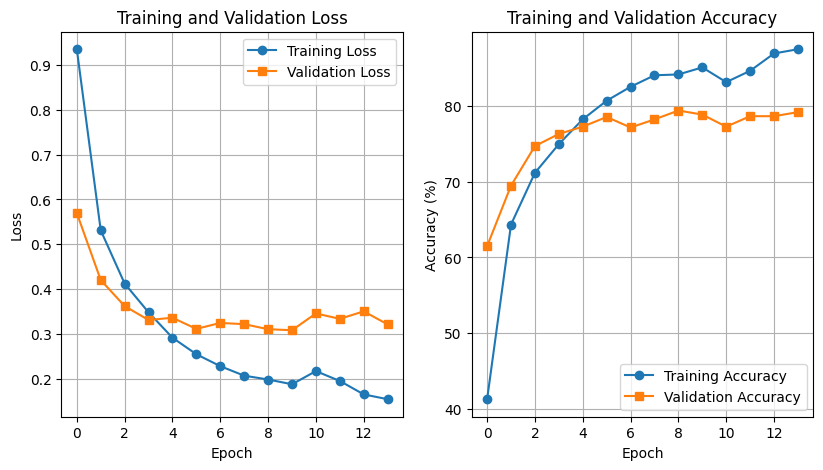

In [16]:
print("\n11. 📈 Training Visualization...")

plt.figure(figsize=(15, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 3, 2)
plt.plot(train_accuracies, label='Training Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# 12. Final Evaluation


12. 📊 Final Evaluation...
📈 Final Results:
   Accuracy: 0.7915
   Precision: 0.7917
   Recall: 0.7915
   F1-Score: 0.7891

📋 Classification Report:
              precision    recall  f1-score   support

         BT1       0.74      0.63      0.68       156
         BT2       0.66      0.70      0.68       156
         BT3       0.75      0.87      0.80       157
         BT4       0.75      0.65      0.70       157
         BT5       0.86      0.95      0.90       157
         BT6       0.99      0.95      0.97       157

    accuracy                           0.79       940
   macro avg       0.79      0.79      0.79       940
weighted avg       0.79      0.79      0.79       940



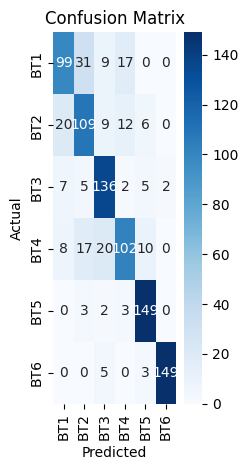

In [17]:
print("\n12. 📊 Final Evaluation...")

model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].squeeze().to(device)

        outputs = model(input_ids, attention_mask)
        _, predicted = torch.max(outputs.data, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert predictions back to original labels
label_names = train_dataset.label_encoder.classes_
pred_labels = train_dataset.label_encoder.inverse_transform(all_predictions)
true_labels = train_dataset.label_encoder.inverse_transform(all_labels)

# Calculate metrics
accuracy = accuracy_score(true_labels, pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='weighted')

print(f"📈 Final Results:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall: {recall:.4f}")
print(f"   F1-Score: {f1:.4f}")

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(true_labels, pred_labels))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=label_names)
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# 13. Save Model

In [18]:
print("\n13. 💾 Saving Model...")
model_save_path = 'bloom_classifier_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'label_encoder': train_dataset.label_encoder,
    'model_config': {
        'num_classes': num_classes,
        'hidden_dim': 256
    }
}, model_save_path)

print(f"✅ Model saved to {model_save_path}")

# Summary
print(f"\n🎉 Pipeline Completed Successfully!")
print(f"   Final Accuracy: {accuracy:.4f}")
print(f"   Model saved: {model_save_path}")
print(f"   Total epochs trained: {len(train_losses)}")
print("=" * 50)


13. 💾 Saving Model...
✅ Model saved to bloom_classifier_model.pth

🎉 Pipeline Completed Successfully!
   Final Accuracy: 0.7915
   Model saved: bloom_classifier_model.pth
   Total epochs trained: 14


# Prediction Results

In [19]:
print("\nDetailed Confusion Matrix Analysis:")
print("=" * 50)

# Print the Confusion Matrix
print("\nConfusion Matrix (Actual vs Predicted):")
print(cm)

# Print true and predicted labels for the test set
print("\nActual vs Predicted Labels for Test Data:")
print("-" * 30)

# Create a list of tuples (Actual, Predicted) for detailed viewing
test_results = list(zip(true_labels, pred_labels))

# You can print a few examples
print("First 10 examples:")
for i in range(min(10, len(test_results))):
    print(f"Example {i+1}: Actual = {test_results[i][0]}, Predicted = {test_results[i][1]}")

print("\nCounts of Actual and Predicted BT Categories in Test Set:")

# Use Counter to show distribution
print("\nActual Label Counts in Test Set:")
print(Counter(true_labels).most_common())

print("\nPredicted Label Counts in Test Set:")
print(Counter(pred_labels).most_common())

print("-" * 50)


Detailed Confusion Matrix Analysis:

Confusion Matrix (Actual vs Predicted):
[[ 99  31   9  17   0   0]
 [ 20 109   9  12   6   0]
 [  7   5 136   2   5   2]
 [  8  17  20 102  10   0]
 [  0   3   2   3 149   0]
 [  0   0   5   0   3 149]]

Actual vs Predicted Labels for Test Data:
------------------------------
First 10 examples:
Example 1: Actual = BT1, Predicted = BT3
Example 2: Actual = BT2, Predicted = BT2
Example 3: Actual = BT5, Predicted = BT5
Example 4: Actual = BT4, Predicted = BT4
Example 5: Actual = BT4, Predicted = BT4
Example 6: Actual = BT2, Predicted = BT4
Example 7: Actual = BT6, Predicted = BT6
Example 8: Actual = BT1, Predicted = BT1
Example 9: Actual = BT2, Predicted = BT2
Example 10: Actual = BT5, Predicted = BT5

Counts of Actual and Predicted BT Categories in Test Set:

Actual Label Counts in Test Set:
[('BT5', 157), ('BT4', 157), ('BT6', 157), ('BT3', 157), ('BT1', 156), ('BT2', 156)]

Predicted Label Counts in Test Set:
[('BT3', 181), ('BT5', 173), ('BT2', 165

# 14. Generate Misclassified Data

In [20]:
print("\n14. ❌ Generating Misclassified Data...")

# Create a DataFrame for the test set with actual and predicted labels
test_df = pd.DataFrame({
    'Questions': X_text_test,
    'Actual': true_labels,
    'Predict': pred_labels
})

# Filter for misclassified instances
misclassified_df = test_df[test_df['Actual'] != test_df['Predict']]

print(f"✅ Found {len(misclassified_df)} misclassified instances.")

# Save misclassified data to CSV
misclassified_csv_path = 'misclassified_data.csv'
misclassified_df.to_csv(misclassified_csv_path, index=False)

print(f"✅ Misclassified data saved to {misclassified_csv_path}")
print("\nFirst 5 misclassified examples:")
print(misclassified_df.head())

print("=" * 50)


14. ❌ Generating Misclassified Data...
✅ Found 196 misclassified instances.
✅ Misclassified data saved to misclassified_data.csv

First 5 misclassified examples:
                                            Questions Actual Predict
0   draw and explain the interfacing diagram of da...    BT1     BT3
5   explain the significance of the position of ru...    BT2     BT4
11  explain electrical method for level measuremen...    BT2     BT1
17  illustrate with a labelled drawing the pathway...    BT2     BT3
27  explain the following operations performed on ...    BT4     BT1


# Export Results

In [21]:
# Generate timestamp and output folder name
embedding_type = "BERT"
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
folder_name = f"{variant}_{embedding_type}_{timestamp}"
os.makedirs(folder_name, exist_ok=True)

# Export steps
export_steps = [
    "Saving training & validation plots",
    "Saving confusion matrix (separate file)",
    "Saving metrics & classification report",
    "Saving predictions",
    "Saving misclassified data",
    "Saving model & zipping folder"
]

for step in tqdm(export_steps, desc="📦 Exporting Outputs", leave=False):
    if step == export_steps[0]:
        # === 1. Save Training & Validation Plots ===
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.plot(train_losses, label='Training Loss', marker='o')
        plt.plot(val_losses, label='Validation Loss', marker='s')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 3, 2)
        plt.plot(train_accuracies, label='Training Accuracy', marker='o')
        plt.plot(val_accuracies, label='Validation Accuracy', marker='s')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 3, 3)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_names, yticklabels=label_names)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')

        plt.tight_layout()
        training_plot_path = os.path.join(folder_name, f"training_plot_{variant}_{timestamp}.png")
        plt.savefig(training_plot_path)
        plt.close()

    elif step == export_steps[1]:
        # === Save Confusion Matrix as Separate File ===
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_names, yticklabels=label_names)
        plt.title('Test Set Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        confusion_matrix_path = os.path.join(folder_name, f"test_confusion_matrix_{variant}_{timestamp}.png")
        plt.tight_layout()
        plt.savefig(confusion_matrix_path)
        plt.close()

    elif step == export_steps[2]:
        # === Save Metrics & Report ===
        metrics_path = os.path.join(folder_name, f"metrics_{variant}_{timestamp}.txt")
        with open(metrics_path, 'w') as f:
            f.write(f"Accuracy: {accuracy:.4f}\n")
            f.write(f"Precision: {precision:.4f}\n")
            f.write(f"Recall: {recall:.4f}\n")
            f.write(f"F1-Score: {f1:.4f}\n")

        report_path = os.path.join(folder_name, f"classification_report_{variant}_{timestamp}.txt")
        with open(report_path, 'w') as f:
            f.write(classification_report(true_labels, pred_labels))

    elif step == export_steps[3]:
        # === Save Predictions ===
        predictions_path = os.path.join(folder_name, f"predictions_{variant}_{timestamp}.txt")
        with open(predictions_path, 'w') as f:
            for i, (actual, predicted) in enumerate(zip(true_labels, pred_labels)):
                f.write(f"{i+1}. Actual: {actual} | Predicted: {predicted}\n")

    elif step == export_steps[4]:
        # === Save Misclassified Data ===
        misclassified_path = os.path.join(folder_name, f"misclassified_{variant}_{timestamp}.csv")
        misclassified_df.to_csv(misclassified_path, index=False)

    elif step == export_steps[5]:
        # === Save Model & Zip Folder ===
        model_path = os.path.join(folder_name, f"model_{variant}_{timestamp}.pth")
        torch.save({
            'model_state_dict': model.state_dict(),
            'label_encoder': train_dataset.label_encoder,
            'model_config': {
                'num_classes': num_classes,
                'hidden_dim': 256,
                'variant': variant
            }
        }, model_path)

        zip_path = f"{folder_name}.zip"
        shutil.make_archive(folder_name, 'zip', folder_name)

print(f"\n✅ All outputs saved in: {folder_name}")
print(f"🗜️ Zipped archive created: {zip_path}")

📦 Exporting Outputs:   0%|          | 0/6 [00:00<?, ?it/s]


✅ All outputs saved in: cnn_BERT_2025-06-10_07-28-56
🗜️ Zipped archive created: cnn_BERT_2025-06-10_07-28-56.zip
